Exact PV: 442.39843385719024


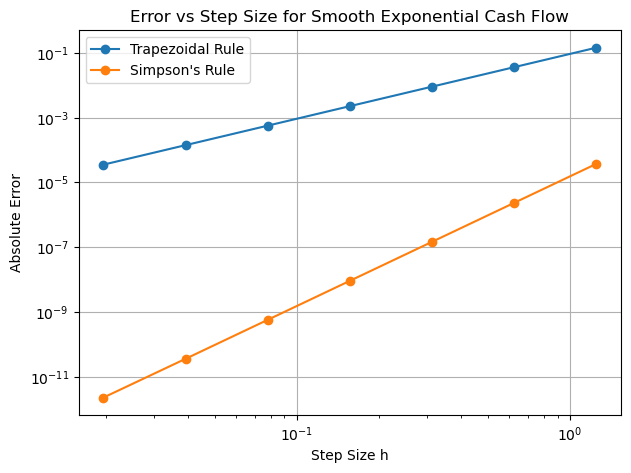

Estimated trapezoidal convergence rate: 1.9999880719988365
Estimated Simpson convergence rate: 3.997143460508117
Oscillatory exact PV approximation: 413.14917624622944


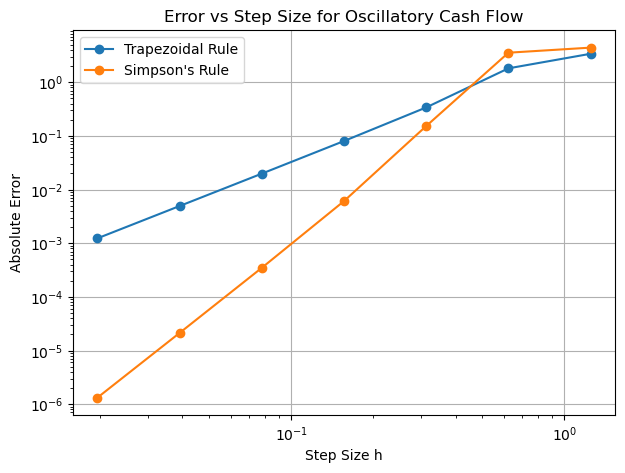

Oscillatory trapezoidal convergence rate: 1.979409895153837
Oscillatory Simpson convergence rate: 3.8743780198731463
Exact PV (multi discontinuous): 498.76960596336954


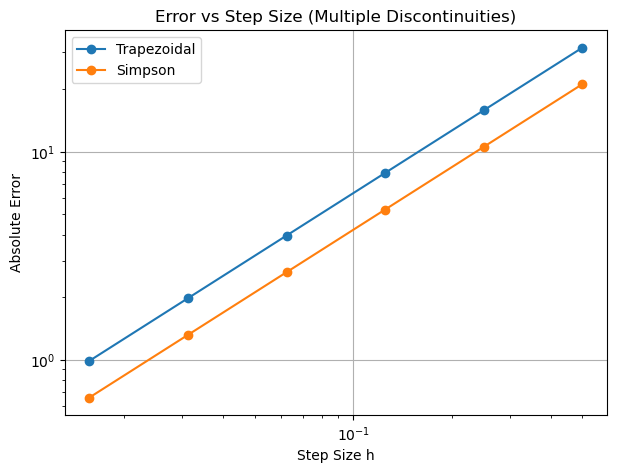

Trapezoidal convergence (multi): 0.9994553867630017
Simpson convergence (multi): 0.9999999253407011


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def trapezoidal_rule(f, a, b, n):
    """
    Approximate the integral of f(t) from a to b using the composite trapezoidal rule.

    Parameters:
        f: function to integrate
        a: left endpoint
        b: right endpoint
        n: number of subintervals

    Returns:
        Approximate integral value
    """
    h = (b - a) / n
    t = np.linspace(a, b, n + 1)
    y = f(t)
    return h * (0.5 * y[0] + np.sum(y[1:-1]) + 0.5 * y[-1])

def simpsons_rule(f, a, b, n):
    """
    Approximate the integral of f(t) from a to b using the composite Simpson's rule. (n must be even bc Simpson's rule uses pairs of intervals)

    Parameters:
        f: function to integrate
        a: left endpoint
        b: right endpoint
        n: number of subintervals

    Returns:
        Approximate integral value
    """
    if n % 2 != 0:
        raise ValueError("n must be even for Simpson's rule.")

    h = (b - a) / n
    t = np.linspace(a, b, n + 1)
    y = f(t)
    return (h / 3) * (y[0] + 4 * np.sum(y[1:-1:2]) + 2 * np.sum(y[2:-1:2]) + y[-1])



# ============================================================
# A) Smooth/exponential Cash Flow Example
# C(t) = 100e^.03t
# ============================================================

C0 = 100
g = 0.03
r = 0.08
T = 5

def discounted_cash_flow(t):
    return C0 * np.exp((g - r) * t)

# Exact present value: Integral of C(t)
exact_pv = C0 * (np.exp((g - r) * T) - 1) / (g - r)

# Test different numbers of subintervals
n_values = [4, 8, 16, 32, 64, 128]
results = []

for n in n_values:
    trap_pv = trapezoidal_rule(discounted_cash_flow, 0, T, n)
    simp_pv = simpsons_rule(discounted_cash_flow, 0, T, n)
    results.append({
        "n": n,
        "h": T / n,
        "Trapezoidal PV": trap_pv,
        "Trapezoidal Error": abs(trap_pv - exact_pv),
        "Simpson PV": simp_pv,
        "Simpson Error": abs(simp_pv - exact_pv)
    })

df = pd.DataFrame(results)
print("Exact PV:", exact_pv)
df


# Different step sizes through different number of intervals (n values)
n_values = [4, 8, 16, 32, 64, 128, 256]
h_vals = []
trap_errors = []
simp_errors = []

for n in n_values:
    h = T / n
    h_vals.append(h)
    trap_approx = trapezoidal_rule(discounted_cash_flow, 0, T, n)
    simp_approx = simpsons_rule(discounted_cash_flow, 0, T, n)
    trap_errors.append(abs(trap_approx - exact_pv))
    simp_errors.append(abs(simp_approx - exact_pv))

# Put results in a table
step_size_results = pd.DataFrame({
    "n": n_values,
    "h": h_vals,
    "Trapezoidal Error": trap_errors,
    "Simpson Error": simp_errors
})
step_size_results

# plot results
plt.figure(figsize=(7, 5))
plt.loglog(h_vals, trap_errors, marker="o", label="Trapezoidal Rule")
plt.loglog(h_vals, simp_errors, marker="o", label="Simpson's Rule")
plt.xlabel("Step Size h")
plt.ylabel("Absolute Error")
plt.title("Error vs Step Size for Smooth Exponential Cash Flow")
plt.legend()
plt.grid(True)
plt.show()

# estimate convergence rate
trap_slope = np.polyfit(np.log(h_vals), np.log(trap_errors), 1)[0]
simp_slope = np.polyfit(np.log(h_vals), np.log(simp_errors), 1)[0]
print("Estimated trapezoidal convergence rate:", trap_slope)
print("Estimated Simpson convergence rate:", simp_slope)


# ============================================================
# B) Oscillatory / Seasonal Cash Flow Example
# C(t) = 100 + 20sin(2πt)
# PV = integral from 0 to T of C(t)e^(-rt) dt
# ============================================================

C_base = 100
A = 20
r = 0.08
T = 5

def oscillatory_discounted_cash_flow(t):
    return (C_base + A * np.sin(2 * np.pi * t)) * np.exp(-r * t)


# Used an AI model to approximate Exact PV for oscillatory model using very fine-grid approximation
# This acts as "ground truth" when the exact integral is annoying.
n_fine = 1_000_000
exact_pv_osc = trapezoidal_rule(oscillatory_discounted_cash_flow, 0, T, n_fine)

n_values = [4, 8, 16, 32, 64, 128, 256]
osc_results = []

for n in n_values:
    h = T / n
    trap_pv = trapezoidal_rule(oscillatory_discounted_cash_flow, 0, T, n)
    simp_pv = simpsons_rule(oscillatory_discounted_cash_flow, 0, T, n)
    osc_results.append({
        "n": n,
        "h": h,
        "Trapezoidal PV": trap_pv,
        "Trapezoidal Error": abs(trap_pv - exact_pv_osc),
        "Simpson PV": simp_pv,
        "Simpson Error": abs(simp_pv - exact_pv_osc)
    })

osc_df = pd.DataFrame(osc_results)
print("Oscillatory exact PV approximation:", exact_pv_osc)
osc_df

# Plot error vs step size for oscillatory cash flow
plt.figure(figsize=(7, 5))
plt.loglog(osc_df["h"], osc_df["Trapezoidal Error"], marker="o", label="Trapezoidal Rule")
plt.loglog(osc_df["h"], osc_df["Simpson Error"], marker="o", label="Simpson's Rule")
plt.xlabel("Step Size h")
plt.ylabel("Absolute Error")
plt.title("Error vs Step Size for Oscillatory Cash Flow")
plt.legend()
plt.grid(True)
plt.show()

# Estimate convergence rates for oscillatory cash flow

osc_trap_slope = np.polyfit(
    np.log(osc_df["h"]),
    np.log(osc_df["Trapezoidal Error"]),
    1
)[0]
osc_simp_slope = np.polyfit(
    np.log(osc_df["h"]),
    np.log(osc_df["Simpson Error"]),
    1
)[0]

print("Oscillatory trapezoidal convergence rate:", osc_trap_slope)
print("Oscillatory Simpson convergence rate:", osc_simp_slope)





# ============================================================
# C) Discontinuous / Piecewise Cash Flow Example
# C(t) = 200 for 0 <= t < 1
#      = 150 for 1 <= t < 2
#      = 100 for 2 <= t <= 3
#      = 75  for 3 <= t <= 4
#      = 50  for 4 <= t <= 5
# PV = integral from 0 to 3 of C(t)e^(-rt) dt
# ============================================================

r = 0.08
T_multi = 5

def discontinuous_multi_cash_flow(t):
    C = np.piecewise(
        t,
        [
            (t >= 0) & (t < 1),
            (t >= 1) & (t < 2),
            (t >= 2) & (t < 3),
            (t >= 3) & (t < 4),
            (t >= 4) & (t <= 5)
        ],
        [200, 150, 100, 75, 50]
    )
    return C * np.exp(-r * t)

# Exact PV (piecewise analytical)

exact_pv_multi = (
    200 * (1 - np.exp(-r * 1)) / r
    + 150 * (np.exp(-r * 1) - np.exp(-r * 2)) / r
    + 100 * (np.exp(-r * 2) - np.exp(-r * 3)) / r
    + 75  * (np.exp(-r * 3) - np.exp(-r * 4)) / r
    + 50  * (np.exp(-r * 4) - np.exp(-r * 5)) / r
)

print("Exact PV (multi discontinuous):", exact_pv_multi)

n_values_multi = [10, 20, 40, 80, 160, 320]
multi_results = []

for n in n_values_multi:
    h = T_multi / n
    trap_pv = trapezoidal_rule(discontinuous_multi_cash_flow, 0, T_multi, n)
    simp_pv = simpsons_rule(discontinuous_multi_cash_flow, 0, T_multi, n)

    multi_results.append({
        "n": n,
        "h": h,
        "Trapezoidal PV": trap_pv,
        "Trapezoidal Error": abs(trap_pv - exact_pv_multi),
        "Simpson PV": simp_pv,
        "Simpson Error": abs(simp_pv - exact_pv_multi)
    })

multi_df = pd.DataFrame(multi_results)
multi_df

plt.figure(figsize=(7, 5))
plt.loglog(multi_df["h"], multi_df["Trapezoidal Error"], marker="o", label="Trapezoidal")
plt.loglog(multi_df["h"], multi_df["Simpson Error"], marker="o", label="Simpson")
plt.xlabel("Step Size h")
plt.ylabel("Absolute Error")
plt.title("Error vs Step Size (Multiple Discontinuities)")
plt.legend()
plt.grid(True)
plt.show()

multi_trap_slope = np.polyfit(
    np.log(multi_df["h"]),
    np.log(multi_df["Trapezoidal Error"]),
    1
)[0]

multi_simp_slope = np.polyfit(
    np.log(multi_df["h"]),
    np.log(multi_df["Simpson Error"]),
    1
)[0]

print("Trapezoidal convergence (multi):", multi_trap_slope)
print("Simpson convergence (multi):", multi_simp_slope)


